# Plot the Cosine similarity versus Iteration number for different fluence

In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt
import torch
import pickle
from IPython.display import display
from vector_ptycho.utils import _to_numpy

device = "cuda" if torch.cuda.is_available() else "cpu"

from vector_ptycho.utils import *
from vector_ptycho.plotting_utils import *
from vector_ptycho.Neel_field_sim_utils import *
from vector_ptycho.reconstruction_utils import *




In [2]:
RGB_scale = make_vector_color_map(plot=False)

In [3]:
device = "cuda" if torch.cuda.is_available() else "cpu"
cdtype = torch.complex64
eps = 1e-8

print(device)

cuda


In [4]:
detector_pixel_size = 6.5e-6 * 4 # Pixel size of the detector (after binning)
wavelength = 1.74e-9 # Wavelength of the X-rays (1.74 nm corresponds to 720 eV)
z = 70e-3 # Sample to detector distance
k = 2 * np.pi / wavelength # Wave number
N = 512 # Number of pixels in the detector
L_detector = N * detector_pixel_size # Detector size

# Define the detector plane coordinates
x_detector = torch.linspace(-L_detector/2, L_detector/2, N, device=device)
y_detector = torch.linspace(-L_detector/2, L_detector/2, N, device=device)
X_detector, Y_detector = torch.meshgrid(x_detector, y_detector, indexing='ij')

# Define the sample plane coordinates
object_pixel_size = (wavelength * z) / (N * detector_pixel_size) # Pixel size in the object/probe plane


L_object = N * object_pixel_size # Object size
x_obj = torch.linspace(-L_object/2, L_object/2, N, device=device)
y_obj = torch.linspace(-L_object/2, L_object/2, N, device=device)
X_obj, Y_obj = torch.meshgrid(x_obj, y_obj, indexing='ij')

print(f"Object pixel size: {object_pixel_size:.2e} m")
print(f"Object size: {L_object:.2e} m")

Object pixel size: 9.15e-09 m
Object size: 4.68e-06 m


In [5]:
H, W = N, N
Lx = N * object_pixel_size
Ly = N * object_pixel_size

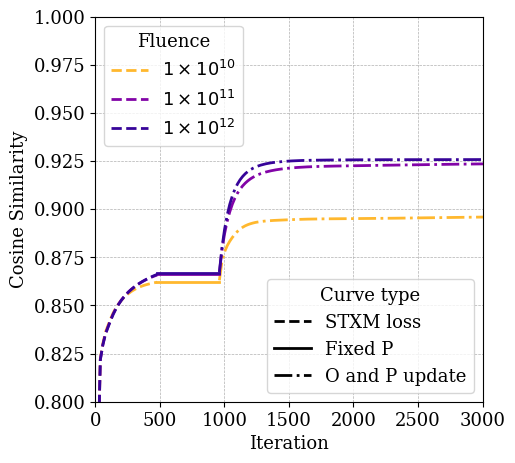

<Figure size 640x480 with 0 Axes>

In [6]:
from matplotlib.lines import Line2D
import matplotlib.pyplot as plt
import matplotlib as mpl

mpl.rcParams['font.family'] = 'Serif'
mpl.rcParams['font.size'] = 13
# Plasma colour scheme
light_yellow = '#ffb82e'
pinky = '#cf4c73'
light_purple = '#8204a7'
dark_purple = '#370499'

run_files_1e10 = [r'.\fluence_1e10\recon_STXM.pt',
              r'.\fluence_1e10\recon_post_STXM.pt',
                r'.\fluence_1e10\recon_post_STXM_2.pt']

run_files_1e11 = [r'.\fluence_1e11\recon_STXM.pt',
              r'.\fluence_1e11\recon_post_STXM.pt',
                r'.\fluence_1e11\recon_post_STXM_2.pt']

run_files_1e12 = [r'.\fluence_1e12\recon_STXM.pt',
              r'.\fluence_1e12\recon_post_STXM.pt',
                r'.\fluence_1e12\recon_post_STXM_2.pt']

# Each stage of the reconstruction has a different line style.
line_styles = ['--', '-', '-.']
colours = [light_yellow, light_purple, dark_purple]

fig, ax = plt.subplots(figsize=(5, 5))

plot_checkpoint_history(
    run_files_1e10,
    label=r"$1\times 10^{10}$",
    ax=ax,
    linewidth=2,
    line_styles=line_styles,
    colour=colours[0]
)
plot_checkpoint_history(
    run_files_1e11,
    label=r"$1\times 10^{11}$",
    ax=ax,
    linewidth=2,
    line_styles=line_styles,
    colour=colours[1]
)
plot_checkpoint_history(
    run_files_1e12,
    label=r"$1\times 10^{12}$",
    ax=ax,
    linewidth=2,
    line_styles=line_styles,
    colour=colours[2]
)

# Colour legend (generated automatically from plotted lines)
colour_legend = ax.legend(title="Fluence", loc="upper left")

# Linestyle legend
style_labels = ["STXM loss", "Fixed P", "O and P update"]

style_handles = [
    Line2D([0], [0], color='black', linestyle=ls, linewidth=2, label=lbl)
    for ls, lbl in zip(line_styles, style_labels)
]

style_legend = ax.legend(
    handles=style_handles,
    title="Curve type",
    loc="lower right"
)

# Add the first legend back after creating the second
ax.add_artist(colour_legend)
# Add a horizontal dashed line at y=1.0 to indicate perfect cosine similarity
#ax.plot([0, 3000], [1.0, 1.0], color='black', linestyle=':', linewidth=1)
ax.set_ylim(0.8, 1.00)
#ax.set_ylim(0.9, 0.95)
ax.set_xlim(0, 3000)
ax.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.show()
plt.savefig("ptycho_recon_progress_1e10_1e11_1e12.svg", dpi=300)

C:\Users\godfrey\Documents\Ptycho development GPU\vector-ptycho\src\vector_ptycho\plotting_utils.py:497: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


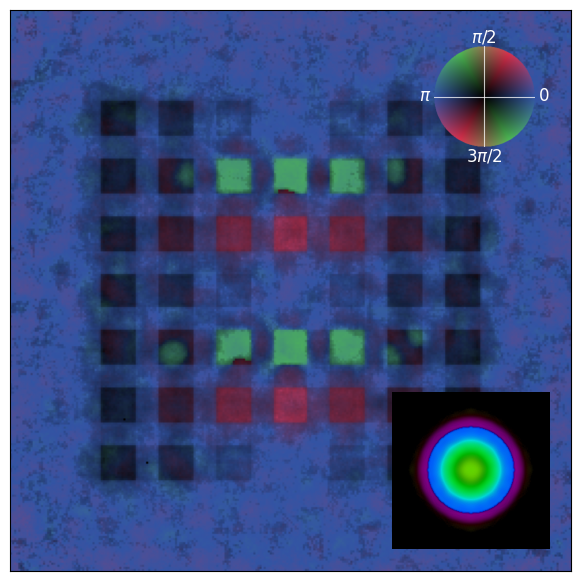

(<Figure size 600x600 with 3 Axes>, <Axes: >)

In [7]:
ckpt = torch.load(r'.\fluence_1e12\recon_post_STXM_2.pt')
l = ckpt['l']

crop_size = 120  # Number of pixels to crop from each edge
X_obj_cropped = X_obj[crop_size:-crop_size, crop_size:-crop_size]
Y_obj_cropped = Y_obj[crop_size:-crop_size, crop_size:-crop_size]
recon_l_cropped = l[:, crop_size:-crop_size, crop_size:-crop_size]
theta, phi = cartesian_to_spherical(recon_l_cropped.detach())
plot_theta_phi_maps(theta, phi, Lx, Ly,
                       positions=None,
                       theta_cmap='magma',
                       phi_cmap=RGB_scale,
                       dx=0.0, dy=0.0,
                       show_positions=True,
                       label_positions=False,
                       label_axes=False,
                       probe_amplitude=ckpt['probe_amplitude'],
                       show_probe_inset=True,
                       probe_inset_crop=200,
                       title_on=False)

# Cross-sections through an edge

C:\Users\godfrey\AppData\Local\Temp\ipykernel_41636\1769625500.py:112: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  data_phi = np.mod(data_phi, np.pi)
C:\Users\godfrey\AppData\Local\Temp\ipykernel_41636\1769625500.py:113: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  data_theta = np.abs(np.cos(data_theta))


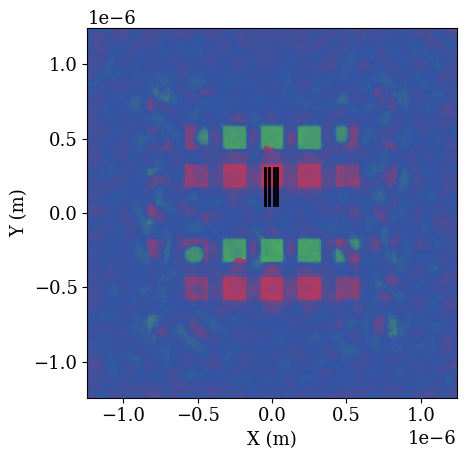

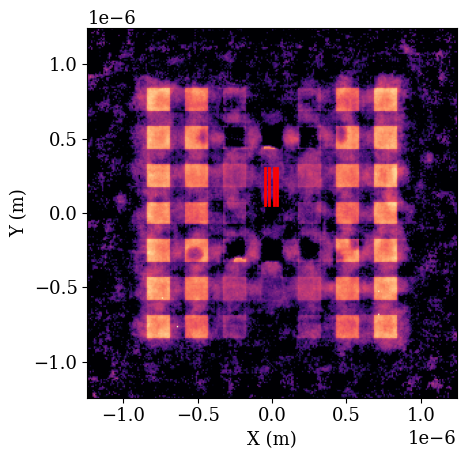

Fitted parameters for data_phi: [-3.32756619e-01  1.21414457e-07 -1.11202966e-08  4.71154104e-01]


C:\Users\godfrey\AppData\Local\Temp\ipykernel_41636\1769625500.py:44: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  _data = np.array(data)


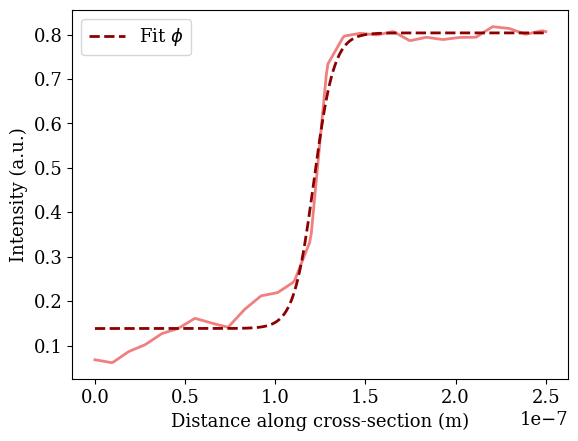

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import RegularGridInterpolator
from scipy.optimize import curve_fit

def extract_cross_section(data, X, Y, start, end, n_points=None):
    """Extract a 1-D cross-section from *data* between two real-world coordinates.

    The line between *start* and *end* is sampled using bilinear interpolation
    on the underlying grid. The x-axis of the returned profile is real
    distance along the line (same units as X, Y).

    This implementation is robust to whether `X, Y` were produced with
    ``meshgrid(indexing='ij')`` or the default ``'xy'``: it derives the
    1-D axes from the unique coordinate values and ensures the data array
    has the expected axis order for ``RegularGridInterpolator``.
    """
    x0, y0 = float(start[0]), float(start[1])
    x1, y1 = float(end[0]),   float(end[1])

    length = np.hypot(x1 - x0, y1 - y0)
    if length == 0:
        raise ValueError("start and end coordinates are identical.")

    if n_points is None:
        n_points = max(X.shape[0], X.shape[1])

    t = np.linspace(0.0, 1.0, n_points)
    line_x = x0 + t * (x1 - x0)
    line_y = y0 + t * (y1 - y0)
    distance = t * length

    # Derive 1-D coordinate axes from the 2-D grids (works for 'ij' or 'xy')
    x_axis = np.unique(X)
    y_axis = np.unique(Y)

    # Ensure ascending order
    if x_axis[0] > x_axis[-1]:
        x_axis = x_axis[::-1]
    if y_axis[0] > y_axis[-1]:
        y_axis = y_axis[::-1]

    # Prepare data so that its shape matches (len(y_axis), len(x_axis))
    _data = np.array(data)
    ny, nx = y_axis.size, x_axis.size
    if _data.shape == (ny, nx):
        pass
    elif _data.shape == (nx, ny):
        _data = _data.T
    else:
        # Try to be helpful if the incoming arrays are transposed from
        # the expected orientation; otherwise raise a clear error.
        if _data.shape[0] == nx and _data.shape[1] == ny:
            _data = _data.T
        else:
            raise ValueError(
                f"data shape {_data.shape} incompatible with derived axes sizes {(ny, nx)}"
            )

    interp = RegularGridInterpolator(
        (y_axis, x_axis), _data, method="linear", bounds_error=False, fill_value=np.nan
    )

    query_pts = np.column_stack([line_y, line_x])
    profile = interp(query_pts)

    return distance, profile, line_x, line_y


def _tanh_model(x, A, x0, w, B):
    """
    Generalised tanh:
 
        f(x) = A * tanh((x - x0) / w) + B
 
    Parameters
    ----------
    A   : amplitude  (half the total swing from trough to peak)
    x0  : inflection point (centre of the transition)
    w   : width parameter  (smaller → steeper transition)
    B   : vertical offset  (midpoint value)
    """
    return A * np.tanh((x - x0) / w) + B

# ---------------------------------------------------------------------------
# Demo
# ---------------------------------------------------------------------------



X, Y = X_obj_cropped.cpu().numpy(), Y_obj_cropped.cpu().numpy()


# Good coordinates for phi resolution test
start = [(-0.02e-6, 0.05e-6), (0.01e-6, 0.05e-6), (-0.05e-6, 0.05e-6), (0.03e-6, 0.05e-6)]
end   = [(-0.02e-6, 0.3e-6), (0.01e-6, 0.3e-6), (-0.05e-6, 0.3e-6), (0.03e-6, 0.3e-6)]
fit_theta = False
fit_phi = True


'''
# Good coordinates for theta resolution test
start = [(0.72e-6, -1.05e-6), (0.75e-6, -1.05e-6), (0.78e-6, -1.05e-6), (0.81e-6, -1.05e-6)]
end   = [(0.72e-6, -0.70e-6), (0.75e-6, -0.70e-6), (0.78e-6, -0.70e-6), (0.81e-6, -0.70e-6)]
fit_theta = True
fit_phi = False
'''

data_theta = theta
data_phi = phi

data_phi = np.mod(data_phi, np.pi)
data_theta = np.abs(np.cos(data_theta))

plt.imshow(data_phi, extent=(X.min(), X.max(), Y.min(), Y.max()), origin='lower', cmap=RGB_scale, vmin=0, vmax=np.pi)
for i in range(0, len(start)):
    plt.plot([start[i][0], end[i][0]], [start[i][1], end[i][1]], 'black', lw=2)
plt.xlabel("X (m)")
plt.ylabel("Y (m)")
plt.show()

plt.imshow(data_theta, extent=(X.min(), X.max(), Y.min(), Y.max()), origin='lower', cmap='magma')
for i in range(0, len(start)):
    plt.plot([start[i][0], end[i][0]], [start[i][1], end[i][1]], 'r-', lw=2)
plt.xlabel("X (m)")
plt.ylabel("Y (m)")
plt.show()

profiles_theta = []
profiles_phi = []

for i in range(0, len(start)):
    distance_theta, profile_theta, line_x, line_y = extract_cross_section(data_theta, X, Y, start=start[i], end=end[i], n_points=None)
    distance_phi, profile_phi, line_x, line_y = extract_cross_section(data_phi, X, Y, start=start[i], end=end[i], n_points=None)

    profiles_theta.append(profile_theta)
    profiles_phi.append(profile_phi)

profiles_theta = np.array(profiles_theta)
profiles_phi = np.array(profiles_phi)

profile_theta = np.mean(profiles_theta, axis=0)
profile_phi = np.mean(profiles_phi, axis=0)
if fit_theta:
    popt_theta, pcov_theta = curve_fit(
    _tanh_model, distance_theta, profile_theta, p0=[1.0, distance_theta[len(distance_theta) // 2], 0.5e-6, 1.0]
    )
    print("Fitted parameters for data_theta:", popt_theta)

if fit_phi:
    popt_phi, pcov_phi = curve_fit(
    _tanh_model, distance_phi, profile_phi, p0=[1.0, distance_phi[len(distance_phi) // 2], 0.5e-6, 1.0]
    )
    print("Fitted parameters for data_phi:", popt_phi)

if fit_theta:
    plt.plot(distance_theta, profile_theta, lw=2, color="steelblue")
    plt.plot(distance_theta, _tanh_model(distance_theta, *popt_theta), lw=2, color="navy", ls="--", label=r"Fit $\theta$")
if fit_phi:
    plt.plot(distance_phi, profile_phi, lw=2, color="lightcoral")
    plt.plot(distance_phi, _tanh_model(distance_phi, *popt_phi), lw=2, color="darkred", ls="--", label=r"Fit $\phi$")


plt.legend()
plt.xlabel("Distance along cross-section (m)")
plt.ylabel("Intensity (a.u.)")
plt.show()

